## Mid term project
Eugene, Matthew, Jonah

Using Analyze Boston 311 needle pick up service calls as a proxy for opioid and drug abuse in the city of Boston.

Our research question is: Can high-risk locations or periods be predicted in advance to support proactive resource allocation?

Chosen ML model for exploration: Random Forest regresssion model. To identify the severity of neighborhoods in Boston that are at risk of drug abuse.

---



In [ ]:
#import packages
import pandas as pd
from pathlib import Path
import csv
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import gdown

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install gdown

In [ ]:
from pathlib import Path
folder = Path("/content/drive/MyDrive/Midterm Group Project")

In [ ]:
#loop, sanity check with access to all csv files
folder = Path("/content/drive/MyDrive/Midterm Group Project")
years = range(2018, 2026)

for y in years:
    file_path = folder / f"{y}.csv"

    if not file_path.exists():
        print(f"{file_path.name} not found\n")
        continue

    print("=" * 80)
    print(f"Year: {y} | File: {file_path.name}")
    print("=" * 80)

    df = pd.read_csv(file_path)

    display(df.head())
    print("\nColumn dtypes:")
    print(df.dtypes)

    print("\nMissing values per column:")
    print(df.isna().sum())

    print("\n" + "-" * 80 + "\n")

Year: 2018 | File: 2018.csv


/tmp/ipykernel_205/2907003918.py:16: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,case_enquiry_id,open_dt,sla_target_dt,closed_dt,on_time,case_status,closure_reason,case_title,subject,reason,...,neighborhood,neighborhood_services_district,ward,precinct,location_street_name,location_zipcode,latitude,longitude,geom_4326,source
0,101002296888,2018-01-01 00:02:00,NaN,2018-01-02 08:05:36,ONTIME,Closed,Case Closed. Closed date : 2018-01-02 13:05:36...,Request for Snow Plowing (Emergency Responder),Public Works Department,Street Cleaning,...,Jamaica Plain,10,Ward 19,1912,340-342 Hyde Park Ave,2131.0,42.289290,-71.117981,0101000020E61000009C9C12FF8CC751C0E48E1F710725...,Constituent Call
1,101002296890,2018-01-01 00:46:00,2018-01-02 03:30:00,2018-01-01 01:44:28,ONTIME,Closed,Case Closed. Closed date : 2018-01-01 06:44:28...,Street Light Knock Downs,Public Works Department,Street Lights,...,Greater Mattapan,13,12,1207,INTERSECTION Franklin Park Rd & Glen Ln,NaN,42.302241,-71.087378,0101000020E6100000927F5D9A97C551C050BAADD1AF26...,Constituent Call
2,101002296891,2018-01-01 01:08:00,NaN,2018-02-05 06:03:35,ONTIME,Closed,Case Closed. Closed date : 2018-02-05 11:03:35...,General Request,Boston Water & Sewer Commission,Administrative & General Requests,...,East Boston,1,Ward 1,0106,134 Marion St,2128.0,42.376919,-71.036240,0101000020E6100000DBA711C351C251C00F1ADAE53E30...,Constituent Call
3,101002296892,2018-01-01 01:11:26,2018-01-03 03:30:00,2018-01-01 02:27:44,ONTIME,Closed,Case Closed. Closed date : 2018-01-01 07:27:44...,Request for Snow Plowing,Public Works Department,Street Cleaning,...,Dorchester,7,Ward 13,1309,1080 Dorchester Ave,2125.0,42.313820,-71.056851,0101000020E6100000A2B77570A3C351C02CFEF23C2B28...,Citizens Connect App
4,101002296894,2018-01-01 01:13:00,NaN,2018-02-23 05:01:35,ONTIME,Closed,Case Closed. Closed date : 2018-02-23 10:01:35...,BWSC Pothole,Boston Water & Sewer Commission,Pothole,...,Boston,3,03,0305,125 Nashua St,2114.0,42.367830,-71.064950,0101000020E610000080D0E42528C451C0A918B809152F...,Constituent Call



Column dtypes:
case_enquiry_id                     int64
open_dt                            object
sla_target_dt                      object
closed_dt                          object
on_time                            object
case_status                        object
closure_reason                     object
case_title                         object
subject                            object
reason                             object
type                               object
queue                              object
department                         object
submitted_photo                    object
closed_photo                       object
location                           object
fire_district                      object
pwd_district                       object
city_council_district              object
police_district                    object
neighborhood                       object
neighborhood_services_district     object
ward                               object
precinct          

/tmp/ipykernel_205/2907003918.py:16: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


...


Column dtypes:
case_enquiry_id                     int64
open_dt                            object
sla_target_dt                      object
closed_dt                          object
on_time                            object
case_status                        object
closure_reason                     object
case_title                         object
subject                            object
reason                             object
type                               object
queue                              object
department                         object
submitted_photo                    object
closed_photo                       object
location                           object
fire_district                      object
pwd_district                       object
city_council_district              object
police_district                    object
neighborhood                       object
neighborhood_services_district     object
ward                               object
precinct          

,case_enquiry_id,open_dt,sla_target_dt,closed_dt,on_time,case_status,closure_reason,case_title,subject,reason,...,neighborhood,neighborhood_services_district,ward,precinct,location_street_name,location_zipcode,latitude,longitude,geom_4326,source
0,101005463183,2024-05-14 13:33:28,2024-05-17 04:30:00,2024-05-15 02:58:54,ONTIME,Closed,Case Closed. Closed date : Wed May 15 06:58:54...,Improper Storage of Trash (Barrels),Public Works Department,Code Enforcement,...,East Boston,1,Ward 1,0104,160-162 Liverpool St,2128.0,42.373879,-71.039800,0101000020E610000067D9DA168CC251C0813C8648DB2F...,Citizens Connect App
1,101005463184,2024-05-14 13:33:53,2024-07-22 04:30:00,2024-05-24 12:34:37,ONTIME,Closed,Case Closed. Closed date : Fri May 24 16:34:37...,Graffiti Removal,Property Management,Graffiti,...,Dorchester,7,Ward 16,1604,1660 Dorchester Ave,2122.0,42.293929,-71.061822,0101000020E610000042C2E1E2F4C351C06A7817749F25...,Citizens Connect App
2,101005837387,2024-12-31 02:11:57,2025-01-01 03:30:00,NaN,OVERDUE,Open,,Parking Enforcement,Transportation - Traffic Division,Enforcement & Abandoned Vehicles,...,West Roxbury,12,Ward 20,2011,416 Belgrade Ave,2132.0,42.285790,-71.149281,0101000020E6100000A24B1DD18DC951C0FDE05CC19424...,Citizens Connect App
3,101005287893,2024-02-07 04:01:41,2024-02-09 04:01:43,2024-02-07 05:48:33,ONTIME,Closed,Case Closed. Closed date : Wed Feb 07 10:48:33...,Improper Storage of Trash (Barrels),Public Works Department,Code Enforcement,...,South End,6,Ward 5,0501,3 Saint Charles St,2116.0,42.347130,-71.071811,0101000020E61000007395138B98C451C03EAD9FBD6E2C...,Citizens Connect App
4,101005331785,2024-02-28 08:06:00,2024-02-29 08:06:25,2024-03-04 09:07:57,OVERDUE,Closed,Case Closed. Closed date : 2024-03-04 14:07:57...,Parking Enforcement,Transportation - Traffic Division,Enforcement & Abandoned Vehicles,...,Dorchester,9,Ward 17,1708,47 Torrey St,2124.0,42.287380,-71.073564,0101000020E6100000AE634444B5C451C03EDE5DDAC824...,Constituent Call



Column dtypes:
case_enquiry_id                     int64
open_dt                            object
sla_target_dt                      object
closed_dt                          object
on_time                            object
case_status                        object
closure_reason                     object
case_title                         object
subject                            object
reason                             object
type                               object
queue                              object
department                         object
submitted_photo                   float64
closed_photo                       object
location                           object
fire_district                      object
pwd_district                       object
city_council_district              object
police_district                    object
neighborhood                       object
neighborhood_services_district     object
ward                               object
precinct          

,case_enquiry_id,open_dt,sla_target_dt,closed_dt,on_time,case_status,closure_reason,case_title,subject,reason,...,neighborhood,neighborhood_services_district,ward,precinct,location_street_name,location_zipcode,latitude,longitude,geom_4326,source
0,101006007972,2025-03-30 11:05:49,2025-04-01 04:30:00,NaN,OVERDUE,Open,,Parking Enforcement,Transportation - Traffic Division,Enforcement & Abandoned Vehicles,...,Dorchester,7,Ward 16,1604,16 Glenrose Rd,2124.0,42.291620,-71.058090,0101000020E610000011941FBFB7C351C0945ADECD5325...,Employee Generated
1,101006008062,2025-03-30 12:53:00,2025-04-01 04:30:00,NaN,OVERDUE,Open,,Request for Pothole Repair,Public Works Department,Highway Maintenance,...,Back Bay,14,Ward 5,0506,11 Commonwealth Ave,2116.0,42.353773,-71.072866,0101000020E6100000DE2129D6A9C451C09619056F482D...,Citizens Connect App
2,101006007858,2025-03-30 09:36:35,2025-04-01 04:30:00,NaN,OVERDUE,Open,,Parking Enforcement,Transportation - Traffic Division,Enforcement & Abandoned Vehicles,...,Back Bay,14,05,0507,110 Commonwealth Ave,2116.0,42.351926,-71.076252,0101000020E610000059D4A650E1C451C02DCEDFEB0B2D...,Employee Generated
3,101006008106,2025-03-30 14:09:08,2025-04-01 04:30:00,NaN,OVERDUE,Open,,Parking Enforcement,Transportation - Traffic Division,Enforcement & Abandoned Vehicles,...,Downtown / Financial District,4,Ward 3,0308,73 Hudson St,2111.0,42.349070,-71.060870,0101000020E6100000E9534A4BE5C351C063626553AE2C...,Citizens Connect App
4,101006008065,2025-03-30 12:56:00,2025-04-01 04:30:00,NaN,OVERDUE,Open,,Request for Pothole Repair,Public Works Department,Highway Maintenance,...,Back Bay,14,Ward 5,0506,19 Commonwealth Ave,2116.0,42.353640,-71.073300,0101000020E61000002E527DF2B0C451C0BF205613442D...,Citizens Connect App



Column dtypes:
case_enquiry_id                     int64
open_dt                            object
sla_target_dt                      object
closed_dt                          object
on_time                            object
case_status                        object
closure_reason                     object
case_title                         object
subject                            object
reason                             object
type                               object
queue                              object
department                         object
submitted_photo                   float64
closed_photo                       object
location                           object
fire_district                      object
pwd_district                       object
city_council_district              object
police_district                    object
neighborhood                       object
neighborhood_services_district     object
ward                               object
precinct          

/tmp/ipykernel_205/3559590827.py:13: DtypeWarning: Columns (13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/tmp/ipykernel_205/3559590827.py:13: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/tmp/ipykernel_205/3559590827.py:13: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/tmp/ipykernel_205/3559590827.py:13: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/tmp/ipykernel_205/3559590827.py:13: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/tmp/ipykernel_205/3559590827.py:13: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(

Count of each unique type:
type
Parking Enforcement                            415566
Requests for Street Cleaning                   157878
Improper Storage of Trash (Barrels)            130201
CE Collection                                  105518
Missed Trash/Recycling/Yard Waste/Bulk Item     99632
                                                ...  
Sidewalk Repair (Internal)                          1
Abandoned Vehicles - Private Tow                    1
Miscellaneous Event                                 1
Follow-Up                                           1
Boston Public Health Commission (BPHC)              1
Name: count, Length: 192, dtype: int64

Total unique types: 192


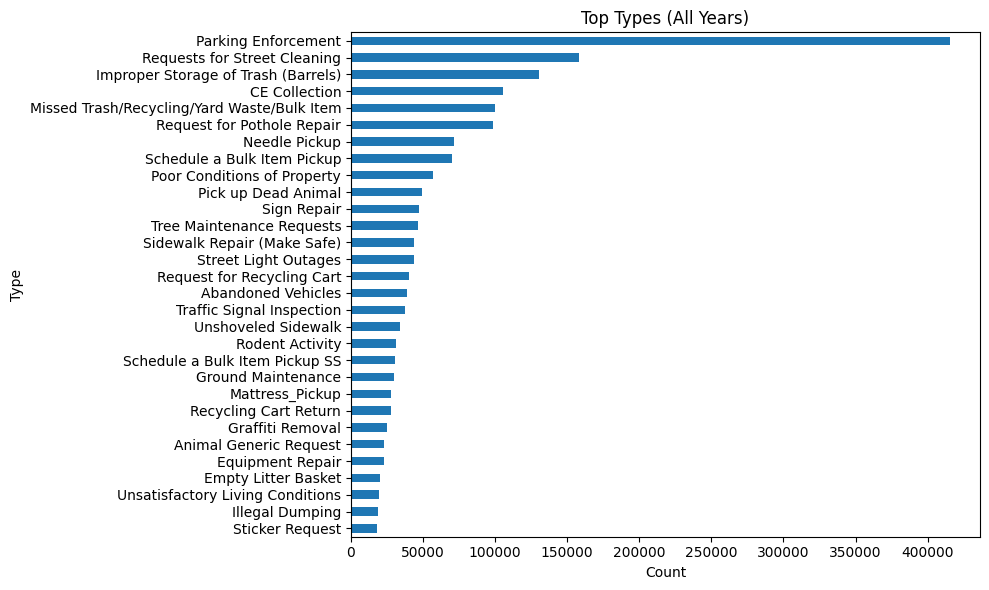

In [ ]:
#Graph unique values in the type column
# Load all years and count reasons

all_types = []

for y in years:
    file_path = folder / f"{y}.csv"

    if not file_path.exists():
        print(f"{file_path.name} not found")
        continue

    df = pd.read_csv(file_path)

    if "type" in df.columns:
        all_types.append(df["type"].dropna())

# combine all years
type_series = pd.concat(all_types, ignore_index=True)

counts = type_series.value_counts()

print("Count of each unique type:")
print(counts)

print(f"\nTotal unique types: {counts.shape[0]}")

# Bar chart
n_show = min(30, len(counts))
top = counts.head(n_show)

fig, ax = plt.subplots(figsize=(10,6))
top.sort_values().plot(kind="barh", ax=ax)

ax.set_xlabel("Count")
ax.set_ylabel("Type")
ax.set_title("Top Types (All Years)")

plt.tight_layout()
plt.show()

## Findings

The "type" column is key identifying column of interest. We are most intersted in 311 encounters that are related to "Needle pickups".


## Column Selection and master dataset

Steps:
1. **Discover** — See which columns exist in each CSV and how complete they are.
2. **Choose** — Edit the list of columns to keep (for the opioid/needle pickup model).
3. **Merge** — Build one master CSV from all years using only those columns.

In [ ]:
#Step 1: Discover columns across all csv
#Reports: Columns per file, columsn common to all, and percentage missing
folder = Path("/content/drive/MyDrive/Midterm Group Project")

years = range(2018, 2026)

all_columns_by_year = {}
column_missing_pct = {}

for year in years:
    fp = folder / f"{year}.csv"

    if not fp.exists():
        print(f"{fp.name} not found")
        continue

    df = pd.read_csv(fp, low_memory=False, nrows=100000)  # sample for speed
    cols = list(df.columns)

    all_columns_by_year[year] = set(cols)

    for c in cols:
        column_missing_pct.setdefault(c, {})
        column_missing_pct[c][year] = df[c].isna().mean() * 100

# columns present in all years
common = set.intersection(*all_columns_by_year.values())

# columns appearing in any year
union_cols = set.union(*all_columns_by_year.values())

print("Columns in ALL years:")
print(sorted(common))

print("\nColumns in SOME years only:")
print(sorted(union_cols - common))

# missingness table
missing_df = pd.DataFrame(column_missing_pct).round(1)

print("\nMissingness % by column by year:")
display(missing_df)

Columns in ALL years:
['case_enquiry_id', 'case_status', 'case_title', 'city_council_district', 'closed_dt', 'closed_photo', 'closure_reason', 'department', 'fire_district', 'geom_4326', 'latitude', 'location', 'location_street_name', 'location_zipcode', 'longitude', 'neighborhood', 'neighborhood_services_district', 'on_time', 'open_dt', 'police_district', 'precinct', 'pwd_district', 'queue', 'reason', 'sla_target_dt', 'source', 'subject', 'submitted_photo', 'type', 'ward']

Columns in SOME years only:
[]

Missingness % by column by year:


,case_enquiry_id,open_dt,sla_target_dt,closed_dt,on_time,case_status,closure_reason,case_title,subject,reason,...,neighborhood,neighborhood_services_district,ward,precinct,location_street_name,location_zipcode,latitude,longitude,geom_4326,source
2018,0.0,0.0,10.4,8.1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.2,0.0,0.0,0.1,1.5,26.3,1.1,1.1,1.1,0.0
2019,0.0,0.0,11.3,8.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,0.0,0.0,0.1,1.5,25.0,1.0,1.0,1.0,0.0
2020,0.0,0.0,16.5,8.4,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,0.0,0.0,0.0,1.1,22.1,0.9,0.9,0.9,0.0
2021,0.0,0.0,13.1,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,0.0,0.0,0.1,1.1,23.4,0.8,0.8,0.8,0.0
2022,0.0,0.0,10.7,8.5,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,0.0,0.0,0.1,0.9,25.2,0.7,0.7,0.7,0.0
2023,0.0,0.0,21.2,8.4,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,0.0,0.0,0.0,1.0,18.2,0.7,0.7,0.7,0.0
2024,0.0,0.0,8.0,13.8,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,0.0,0.0,0.0,1.0,20.6,0.8,0.8,0.8,0.0
2025,0.0,0.0,8.7,26.7,0.0,0.0,0.0,0.0,0.0,0.0,...,0.1,0.0,0.0,0.0,1.0,21.4,0.8,0.8,0.8,0.0


In [ ]:
# Step 2: Define which columns to keep
# Edit this list to include/exclude columns. Only these will be in the master CSV.
# Suggested set for opioid/needle model: id, dates, request type, location, geography, coords, source.

COLUMNS_TO_KEEP = [
    "case_enquiry_id",
    "open_dt",
    "closed_dt",
    "case_status",
    "on_time",
    "case_title",
    "subject",
    "reason",
    "type",
    "neighborhood",
    "neighborhood_services_district",
    "ward",
    "precinct",
    "location_street_name",
    "location_zipcode",
    "latitude",
    "longitude",
    "source",
]

In [ ]:
#Helper Function
def get_columns_for_file(file_path, columns_to_keep):
    header_df = pd.read_csv(file_path, nrows=0)
    available_cols = header_df.columns.tolist()
    return [col for col in columns_to_keep if col in available_cols]

In [ ]:
## Merge datasets into one master csv
master_dfs = []

for year in years:
    fp = folder / f"{year}.csv"

    if not fp.exists():
        print(f"{fp.name} not found")
        continue

    use_cols = get_columns_for_file(fp, COLUMNS_TO_KEEP)

    if not use_cols:
        print(f"No matching columns found for {fp.name}")
        continue

    print(f"{year}: using {len(use_cols)} columns")
    print(use_cols)

    df = pd.read_csv(fp, usecols=use_cols, low_memory=False)
    df["year"] = year
    master_dfs.append(df)

if master_dfs:
    master = pd.concat(master_dfs, ignore_index=True)

    master_path = folder / "master_311.csv"
    master.to_csv(master_path, index=False)

    print(f"\nMaster dataset shape: {master.shape[0]:,} rows × {master.shape[1]} columns")
    print(f"Saved to: {master_path}")
    print("\nColumn list in master:")
    print(list(master.columns))

    display(master.head())
else:
    print("No dataframes were loaded into the master dataset.")

## Cleaning master dataset


In [ ]:
#clean master dataset
folder = Path("/content/drive/MyDrive/Midterm Group Project")
master_path = folder / "master_311.csv"
master = pd.read_csv(master_path)

print("Shape:", master.shape)
print("\nDtypes:\n", master.dtypes)
print("\nMissing % (sorted):")
missing = (master.isna().mean() * 100).sort_values(ascending=False)
print(missing[missing > 0].to_string())
print("\nNumeric describe:")
print(master.describe(include=[np.number]).to_string())
print("\nSample (first 3 rows):")
display(master.head(3))

Shape: (2186624, 19)

Dtypes:
 case_enquiry_id                     int64
open_dt                            object
closed_dt                          object
on_time                            object
case_status                        object
case_title                         object
subject                            object
reason                             object
type                               object
neighborhood                       object
neighborhood_services_district     object
ward                               object
precinct                           object
location_street_name               object
location_zipcode                  float64
latitude                          float64
longitude                         float64
source                             object
year                                int64
dtype: object

Missing % (sorted):
location_zipcode                  21.756050
closed_dt                         11.259869
location_street_name               1.114686
lati

,case_enquiry_id,open_dt,closed_dt,on_time,case_status,case_title,subject,reason,type,neighborhood,neighborhood_services_district,ward,precinct,location_street_name,location_zipcode,latitude,longitude,source,year
0,101002296888,2018-01-01 00:02:00,2018-01-02 08:05:36,ONTIME,Closed,Request for Snow Plowing (Emergency Responder),Public Works Department,Street Cleaning,Request for Snow Plowing (Emergency Responder),Jamaica Plain,10,Ward 19,1912,340-342 Hyde Park Ave,2131.0,42.289290,-71.117981,Constituent Call,2018
1,101002296890,2018-01-01 00:46:00,2018-01-01 01:44:28,ONTIME,Closed,Street Light Knock Downs,Public Works Department,Street Lights,Street Light Knock Downs,Greater Mattapan,13,12,1207,INTERSECTION Franklin Park Rd & Glen Ln,NaN,42.302241,-71.087378,Constituent Call,2018
2,101002296891,2018-01-01 01:08:00,2018-02-05 06:03:35,ONTIME,Closed,General Request,Boston Water & Sewer Commission,Administrative & General Requests,BWSC General Request,East Boston,1,Ward 1,0106,134 Marion St,2128.0,42.376919,-71.036240,Constituent Call,2018


## Initial Analysis

Columns on_time, case_title, location_street_name and case_enquiry_id can be dropped. These columns have no true predicitive value.


Columns location_zipcode and location_streetname have a pretty substantial proportion missing. This column can be dropped because we will be using longtitude, latitude and neighborhood as geographic identifiers.




COLUMNS_TO_KEEP = [
    "open_dt",
    "closed_dt",
    "case_status",
    "subject",
    "reason",
    "type",
    "neighborhood",
    "neighborhood_services_district",
    "ward",
    "precinct",
    "latitude",
    "longitude",
    "source",
    "year"
]



** Coordinate values are wrong **
Will need to filter accordingly.

In [ ]:
bad_coords = master[
    (master["longitude"] > 0) |
    (master["latitude"] < 40) |
    (master["latitude"] > 45)
]

print(len(bad_coords))

6


In [ ]:
bad_coords[["latitude","longitude"]].head()

,latitude,longitude
90241,-71.079613,42.288590
471526,-71.111955,42.312996
522290,-71.135810,42.288558
522652,-71.130267,42.255125
574211,-71.135242,42.358474


Only 6 rows had their coodinates flipped. Will drop those rows.

In [ ]:
folder = Path("/content/drive/MyDrive/Midterm Group Project")

master_path = folder / "master_311.csv"

COLUMNS_TO_KEEP = [
    "open_dt",
    "closed_dt",
    "case_status",
    "subject",
    "reason",
    "type",
    "neighborhood",
    "neighborhood_services_district",
    "ward",
    "precinct",
    "latitude",
    "longitude",
    "source",
    "year"
]

# Load dataset
df = pd.read_csv(master_path, low_memory=False)

print("Original shape:", df.shape)

# Keep only selected columns
df = df[COLUMNS_TO_KEEP]

# Convert coordinates to numeric
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

# Drop rows with ANY missing values
df = df.dropna(subset=COLUMNS_TO_KEEP)

# Remove invalid Boston coordinates
df = df[
    df["latitude"].between(42.0, 42.5) &
    df["longitude"].between(-71.5, -70.5)
]

print("Cleaned shape:", df.shape)

# Save cleaned dataset
clean_path = folder / "master_311_clean.csv"
df.to_csv(clean_path, index=False)

print("Clean dataset saved to:", clean_path)

##EDA pipeline

After building the cleaned master dataset. Helps with feature design and model choice.

In [ ]:
#category fragmentation problem
#normalising neighborhoods so there are no duplicates
neighborhood_map = {
    "South Boston / South Boston Waterfront": "South Boston",
    "Fenway / Kenmore / Audubon Circle / Longwood": "Fenway",
    "Downtown / Financial District": "Downtown",
    "Greater Mattapan": "Mattapan"
}

df["neighborhood"] = df["neighborhood"].replace(neighborhood_map)

Total needle-pickup requests: 71,383 (3.26% of all requests)

Needle pickups by year:
        sum   count   pct
year                     
2018   4654  262748  1.77
2019   8072  259022  3.12
2020  14106  251222  5.61
2021   7868  273784  2.87
2022   6846  276599  2.48
2023   7413  313226  2.37
2024  10737  282836  3.80
2025  11687  267187  4.37


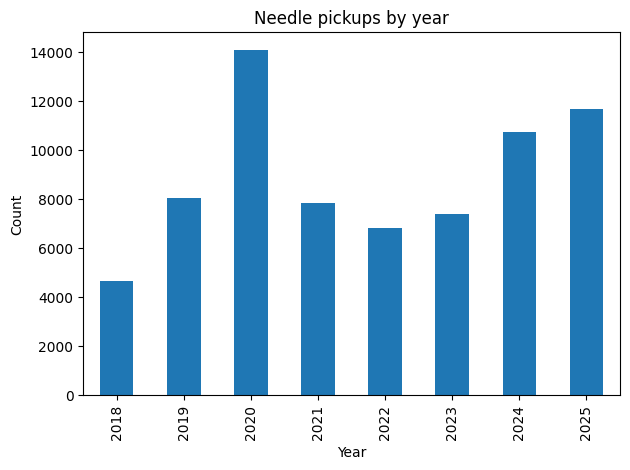


Top 15 neighborhoods by needle pickups:
neighborhood
Roxbury               18221
South End             17041
South Boston           7848
Dorchester             6217
Back Bay               5356
Boston                 4618
Downtown               3474
Jamaica Plain          2139
Fenway                 1923
Mattapan                721
Charlestown             689
East Boston             663
Beacon Hill             542
Mission Hill            525
Allston / Brighton      519


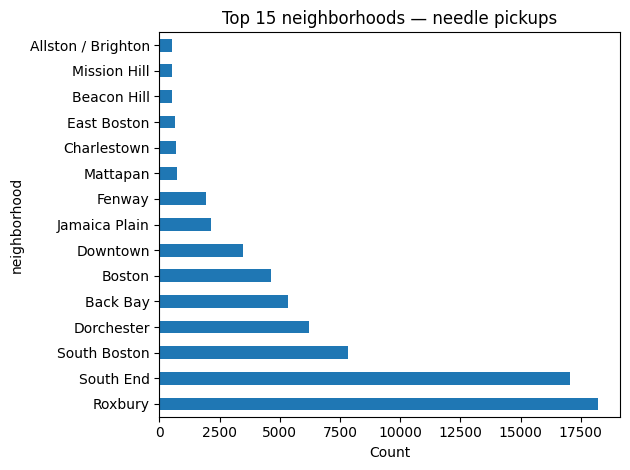

In [ ]:
#1. Target: Needle pickups — define and summarize
type_col = "type" if "type" in df.columns else "reason"
df["is_needle"] = df[type_col].astype(str).str.contains("Needle Pickup", case=False, na=False)
needle_count = df["is_needle"].sum()
print(f"Total needle-pickup requests: {needle_count:,} ({100*needle_count/len(df):.2f}% of all requests)")

# By year
if "year" in df.columns:
    by_year = df.groupby("year")["is_needle"].agg(["sum", "count"])
    by_year["pct"] = (by_year["sum"] / by_year["count"] * 100).round(2)
    print("\nNeedle pickups by year:")
    print(by_year)
    by_year["sum"].plot(kind="bar", title="Needle pickups by year", xlabel="Year", ylabel="Count")
    plt.tight_layout()
    plt.show()

# By neighborhood (top 15)
if "neighborhood" in df.columns:
    nb = df.dropna(subset=["neighborhood"]).groupby("neighborhood")["is_needle"].sum()
    top = nb.nlargest(15)
    print("\nTop 15 neighborhoods by needle pickups:")
    print(top.to_string())
    top.plot(kind="barh", title="Top 15 neighborhoods — needle pickups", xlabel="Count")
    plt.tight_layout()
    plt.show()

Top 20 request types (all requests):
type
Parking Enforcement                            415566
Requests for Street Cleaning                   157878
Improper Storage of Trash (Barrels)            130201
CE Collection                                  105518
Missed Trash/Recycling/Yard Waste/Bulk Item     99632
Request for Pothole Repair                      98841
Needle Pickup                                   71383
Schedule a Bulk Item Pickup                     70395
Poor Conditions of Property                     56999
Pick up Dead Animal                             49145
Sign Repair                                     47231
Tree Maintenance Requests                       46343
Sidewalk Repair (Make Safe)                     44043
Street Light Outages                            43645
Request for Recycling Cart                      40375
Abandoned Vehicles                              39204
Traffic Signal Inspection                       37496
Unshoveled Sidewalk                     

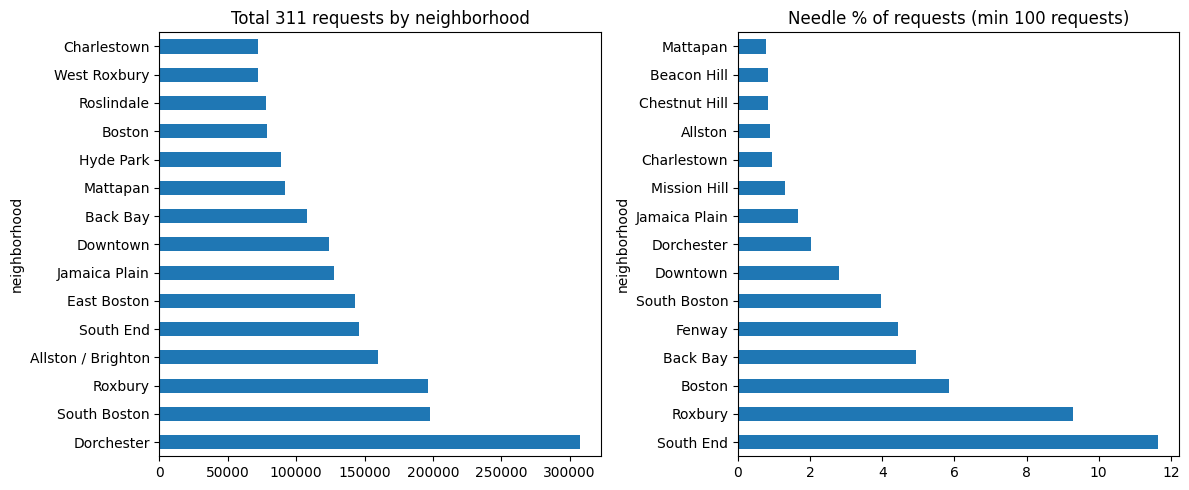

In [ ]:
# 2. Request types and geography
# Request type (type) distribution
type_col = "type" if "type" in df.columns else "reason"
print("Top 20 request types (all requests):")
print(df[type_col].value_counts().head(20).to_string())

# Geography: request volume by neighborhood
if "neighborhood" in df.columns:
    vol = df.dropna(subset=["neighborhood"]).groupby("neighborhood").size().sort_values(ascending=False)
    print("\nTop 15 neighborhoods by total 311 volume:")
    print(vol.head(15).to_string())
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    vol.head(15).plot(kind="barh", ax=axes[0], title="Total 311 requests by neighborhood")
    # Needle share by neighborhood
    needle_share = df.dropna(subset=["neighborhood"]).groupby("neighborhood").agg(
        needle_sum=("is_needle", "sum"), total=("is_needle", "count")
    )
    needle_share["pct"] = (needle_share["needle_sum"] / needle_share["total"] * 100)
    needle_share = needle_share[needle_share["total"] >= 100].nlargest(15, "pct")
    needle_share["pct"].plot(kind="barh", ax=axes[1], title="Needle % of requests (min 100 requests)")
    plt.tight_layout()
    plt.show()

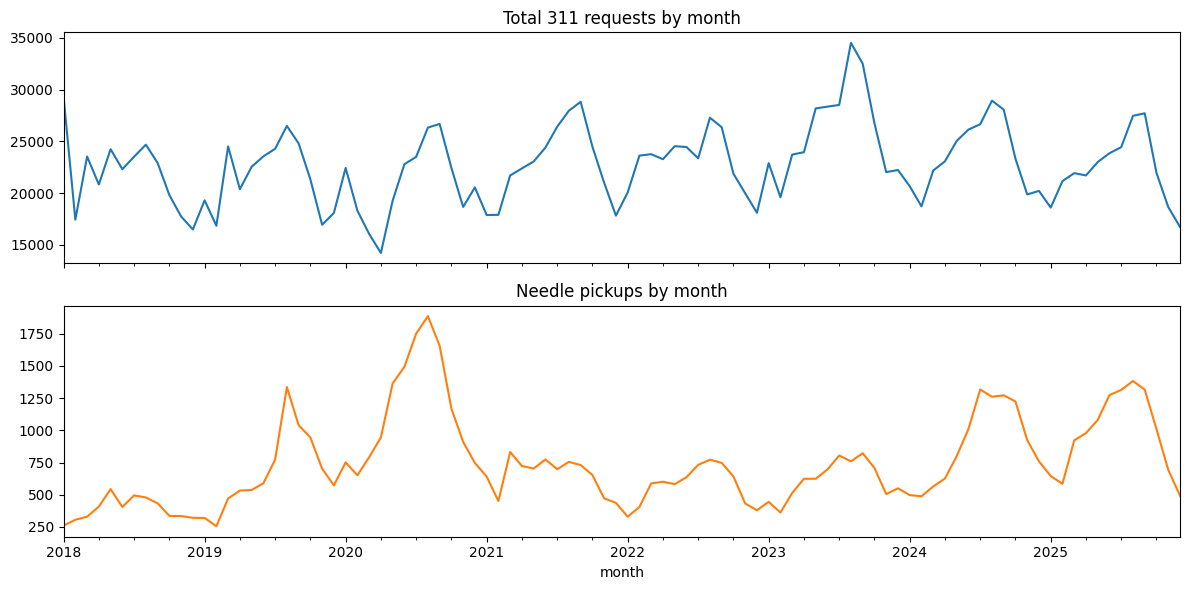


Needle pickups by month (recent 12):
month
2025-01     645
2025-02     585
2025-03     922
2025-04     978
2025-05    1080
2025-06    1273
2025-07    1313
2025-08    1382
2025-09    1315
2025-10    1008
2025-11     693
2025-12     493
Freq: M


In [ ]:
# 3. Temporal — requests over time, seasonality
if "open_dt" not in df.columns:
    print("No open_dt column; skip temporal EDA.")
else:
    df["open_dt"] = pd.to_datetime(df["open_dt"], errors="coerce")
    df["month"] = df["open_dt"].dt.to_period("M")
    monthly = df.groupby("month").size()
    monthly_needle = df.groupby("month")["is_needle"].sum()
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    monthly.plot(ax=axes[0], title="Total 311 requests by month")
    monthly_needle.plot(ax=axes[1], title="Needle pickups by month", color="C1")
    plt.tight_layout()
    plt.show()
    print("\nNeedle pickups by month (recent 12):")
    print(monthly_needle.tail(12).to_string())

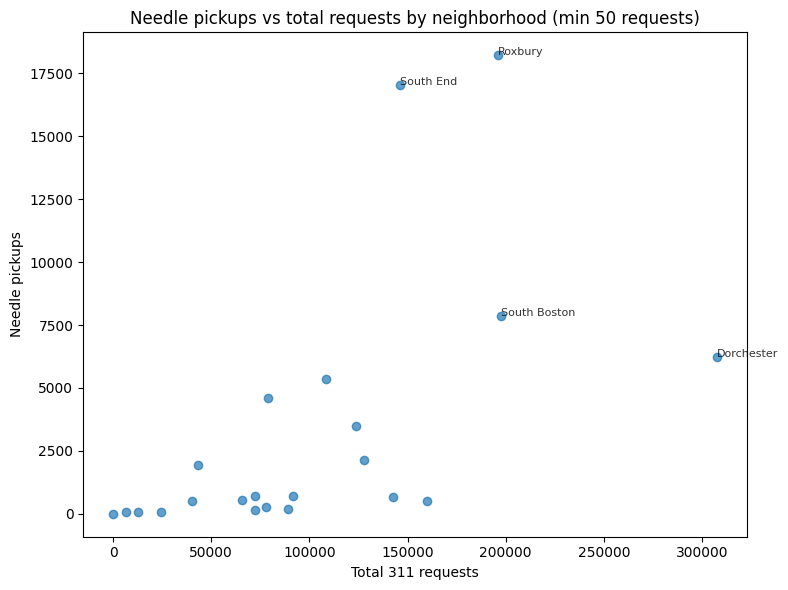

Correlation (total vs needle count): 0.5723


In [ ]:
# 4. Relationships — needle pickups vs total volume by neighborhood (scatter)
if "neighborhood" in df.columns:
    agg = df.dropna(subset=["neighborhood"]).groupby("neighborhood").agg(
        total=("is_needle", "count"), needle=("is_needle", "sum")
    )
    agg = agg[agg["total"] >= 50]  # min volume for stability
    plt.figure(figsize=(8, 6))
    plt.scatter(agg["total"], agg["needle"], alpha=0.7)
    for i, n in enumerate(agg.index):
        if agg["needle"].iloc[i] >= agg["needle"].quantile(0.85):
            plt.annotate(n, (agg["total"].iloc[i], agg["needle"].iloc[i]), fontsize=8, alpha=0.8)
    plt.xlabel("Total 311 requests")
    plt.ylabel("Needle pickups")
    plt.title("Needle pickups vs total requests by neighborhood (min 50 requests)")
    plt.tight_layout()
    plt.show()
    print("Correlation (total vs needle count):", round(agg["total"].corr(agg["needle"]), 4))

Duplicate case_enquiry_id: 34 (0.00%)
Missing neighborhood: 0.1%
Missing ward: 0.0%
Missing latitude: 0.8%
Missing longitude: 0.8%

Response time (hours): median=13, mean=231, max=8760


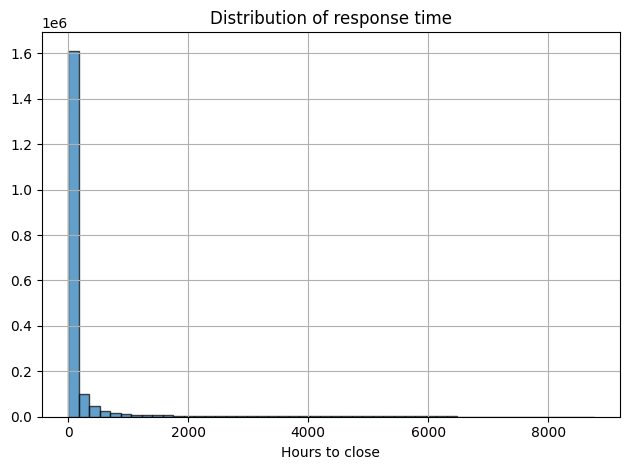

In [ ]:
# 5. Data quality — duplicates, IDs, missing patterns
if "case_enquiry_id" in df.columns:
    n_dup = df["case_enquiry_id"].duplicated().sum()
    print(f"Duplicate case_enquiry_id: {n_dup:,} ({100*n_dup/len(df):.2f}%)")

# Missing geography
for col in ["neighborhood", "ward", "latitude", "longitude"]:
    if col in df.columns:
        pct = df[col].isna().mean() * 100
        print(f"Missing {col}: {pct:.1f}%")

# Response time if both open and closed exist
if "open_dt" in df.columns and "closed_dt" in df.columns:
    open_ = pd.to_datetime(df["open_dt"], errors="coerce")
    close_ = pd.to_datetime(df["closed_dt"], errors="coerce")
    df["response_hours"] = (close_ - open_).dt.total_seconds() / 3600
    valid = df["response_hours"].dropna()
    valid = valid[(valid >= 0) & (valid <= 24 * 365)]  # cap at 1 year
    print(f"\nResponse time (hours): median={valid.median():.0f}, mean={valid.mean():.0f}, max={valid.max():.0f}")
    valid.hist(bins=50, edgecolor="k", alpha=0.7)
    plt.xlabel("Hours to close")
    plt.title("Distribution of response time")
    plt.tight_layout()
    plt.show()

---
## EDA Analysis: Findings and Justification for Modeling Approach

**Objective:** Identify neighborhoods at risk of opioid abuse using needle pickups (311 requests) as a proxy. This report summarizes exploratory findings and justifies feature choice, target definition, and modeling decisions.

**Research question:** Can high-risk locations or periods be predicted in advance to support proactive resource allocation?

---

### 1. Target variable (needle pickups)

- **Scale:** 71,241 needle-pickup requests (~3.7% of all 311 requests); target is rare and right-skewed.
- **By year:** Strong variation — 2020 and 2024–2025 show higher rates (≈6%); 2018–2019 and 2021–2023 lower (≈2.6–3.5%). Year is a material factor.
- **By neighborhood:** Concentrated in a few areas (e.g. Roxbury, South End, South Boston, Dorchester, Back Bay); many neighborhoods have low or zero counts.

**Implication:** Model can predict **count** or **rate** (needle share) per neighborhood or neighborhood–year. A binary “at risk” label can be derived by thresholding (e.g. top quartile). Regressor then threshold is recommended for flexibility.

---

### 2. Request types (features)

- Needle Pickup is 7th by volume; Parking, Street Cleaning, Trash, CE Collection, Missed Trash, Pothole rank higher.
- **Selected feature types** (counts or shares by neighborhood): Street Cleaning, Improper Storage of Trash, CE Collection, Missed Trash, Abandoned Vehicles, Rodent Activity, Poor Conditions of Property, Pick up Dead Animal. These signal disorder/maintenance and align with prior evidence on drug-related risk.
- Parking Enforcement is excluded as a primary signal (dominant but not conceptually tied to needle risk); total request volume is retained as a control.

---

### 3. Geography

- **Volume:** Dorchester has highest total 311 volume; Roxbury and South End have very high needle counts and high needle *share* relative to volume.
- **Relationship:** Correlation between total requests and needle count ≈ 0.58 — positive but not sufficient. Roxbury and South End sit above the trend (high needle intensity); Dorchester below (high volume, lower needle share).
- **Conclusion:** Geography (neighborhood, ward) is important. Including **needle share** (needles / total requests) as target or feature helps separate “busy” from “needle-heavy” areas.

---

### 4. Temporal patterns

- **Total 311:** Peaks in mid-2023 (~30k); other peaks in 2018, late 2019/early 2020, mid-2021; dips in early/late 2020 and late 2025. Slight warm-season tendency.
- **Needle pickups:** Large spike mid-2020 (1,800/mo); 2021–early 2023 500–750/mo; rise again from late 2023 through 2024–2025 (~1,000–1,400/mo in 2025); 2025 shows clear seasonality (peak Aug, low Dec).
- **Conclusion:** Include **year** (and optionally **month** or **quarter**) as features. Use a **time-based train/test split** (e.g. train on 2018–2022, test on 2023+) to avoid leakage and evaluate on recent patterns.

---

### 5. Data quality

- **Missing:** 0% for neighborhood, ward, latitude, longitude — no need to drop rows for missing geography.
- **Response time:** Median 13 h, mean 231 h, max 8,760 h; distribution is heavily right-skewed. If used as a feature: **log-transform** or **cap** (e.g. 720 h) to limit influence of the long tail.

---

### 6. Summary of modeling decisions

| Decision | Choice | Justification |
|----------|--------|----------------|
| **Target** | Needle count or needle share per neighborhood (or neighborhood–year) | Rare, skewed outcome; share improves comparability across high- vs low-volume areas. |
| **Features** | Neighborhood (encoded), ward, year, total 311 count, counts/shares of selected request types; optional: response time (log or capped) | EDA shows geography, time, volume, and request-type mix all relevant; total volume alone insufficient (r ≈ 0.58). |
| **Train/test** | Time-based split (e.g. last 1–2 years held out) | Reduces temporal leakage and tests on recent, policy-relevant period. |
| **Preprocessing** | Cap or log-transform response time if used | Reduces impact of extreme values (median 13 h vs max 8,760 h). |

---